# Student Performance Prediction System

## Machine Learning Project

This project predicts student performance based on study hours, attendance and previous marks using Machine Learning.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Creating Dataset

In this project, we use student data containing study hours, attendance, previous marks and final marks.

In [2]:
data = {
    "Study_Hours": [2,3,5,7,8,6,4,9,1,10],
    "Attendance": [60,65,75,85,90,80,70,95,50,98],
    "Previous_Marks": [50,55,65,75,85,70,60,90,40,95],
    "Final_Marks": [55,60,70,80,90,75,65,95,45,98]
}

df = pd.DataFrame(data)

df

,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,2,60,50,55
1,3,65,55,60
2,5,75,65,70
3,7,85,75,80
4,8,90,85,90
5,6,80,70,75
6,4,70,60,65
7,9,95,90,95
8,1,50,40,45
9,10,98,95,98


## 2. Data Understanding

Checking dataset information and missing values.

In [3]:
df.head()

,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,2,60,50,55
1,3,65,55,60
2,5,75,65,70
3,7,85,75,80
4,8,90,85,90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     10 non-null     int64
 1   Attendance      10 non-null     int64
 2   Previous_Marks  10 non-null     int64
 3   Final_Marks     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [5]:
df.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Final_Marks,0


## 3. Exploratory Data Analysis (EDA)

Data visualization helps us understand the relationship between different features and student performance.

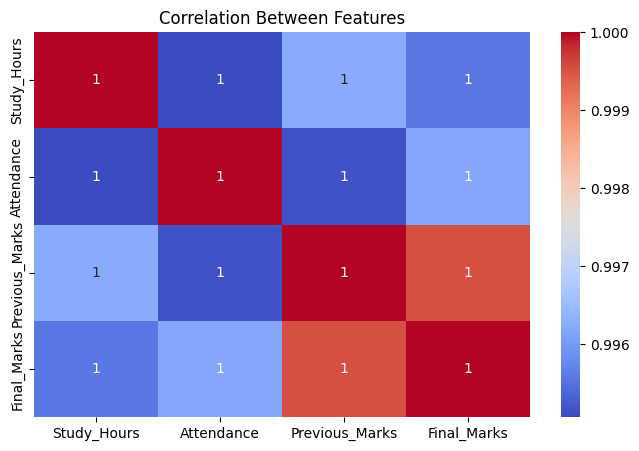

In [6]:
# Correlation Heatmap

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Features")

plt.show()

### Relationship between Study Hours and Final Marks

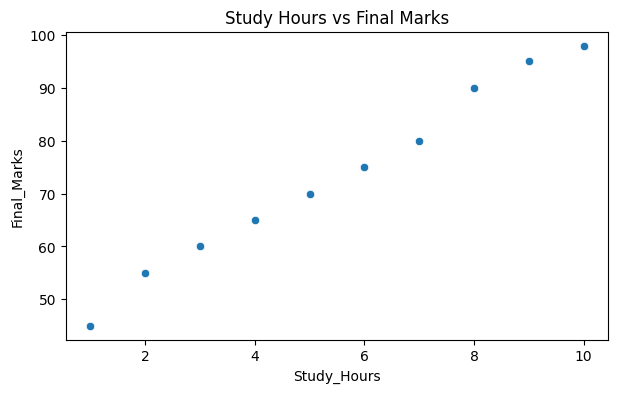

In [7]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    x="Study_Hours",
    y="Final_Marks",
    data=df
)

plt.title("Study Hours vs Final Marks")

plt.show()

### Relationship between Attendance and Final Marks

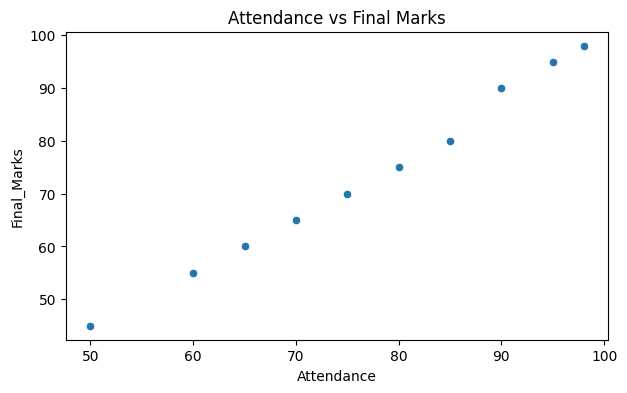

In [8]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    x="Attendance",
    y="Final_Marks",
    data=df
)

plt.title("Attendance vs Final Marks")

plt.show()

## 4. Feature Selection

Selecting input features and target variable for Machine Learning model.

Features:
- Study Hours
- Attendance
- Previous Marks

Target:
- Final Marks

In [9]:
# Selecting input features (X) and output (y)

X = df[["Study_Hours", "Attendance", "Previous_Marks"]]

y = df["Final_Marks"]

X.head()

,Study_Hours,Attendance,Previous_Marks
0,2,60,50
1,3,65,55
2,5,75,65
3,7,85,75
4,8,90,85


## 5. Splitting Dataset

The dataset is divided into training and testing data.

Training data is used to train the model.
Testing data is used to evaluate model performance.

In [10]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 3)
Testing Data: (2, 3)


## 6. Model Training

We use Linear Regression algorithm to predict student final marks.

In [11]:
# Creating and training the model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## 7. Model Prediction

The trained model predicts final marks for test data.

In [12]:
# Making predictions

y_pred = model.predict(X_test)

y_pred

array([40., 60.])

## 8. Model Evaluation

We evaluate the performance of the Machine Learning model using evaluation metrics.

Metrics used:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R2 Score

In [13]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 2.5
Mean Squared Error: 12.5
R2 Score: 0.7777777777777778


## 9. Predicting Performance for New Student

The trained model can predict final marks for a new student's input data.

In [14]:
# Taking new student data

new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Marks": [75]
})

# Prediction

prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 85.00000000000001


## 10. Saving Trained Model

The trained model is saved so it can be used later in an application.

In [15]:
import pickle

with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


## 11. Saving Dataset

Saving the dataset as a CSV file.

In [16]:
df.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully
